# Predicting ad Click-Through Rate with logistic regression (SGD)

You are interviewing with an ad team. The task: predict the **click-through rate
(CTR)** of an ad from categorical context (site, app, device, position, hour). The
classic benchmark is the [Avazu CTR dataset](https://www.kaggle.com/competitions/avazu-ctr-prediction/data);
the markdown below shows how to plug it in. So the notebook runs anywhere, it
also ships a synthetic generator that mirrors the Avazu schema (high-cardinality
IDs and a realistic ~17% click rate).

**You will implement**
- the **hashing trick** for high-cardinality categorical features,
- the log-loss gradient (derived by hand) and **logistic regression trained with SGD**,
- imbalance-aware evaluation: log-loss, the **precision-recall** curve, average precision,

**and then investigate**
- how the hash dimension trades memory against collisions, and
- whether your predicted probabilities are **calibrated** (which ad auctions require).


## Setup

In [1]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

## The data

Real CTR features are mostly high-cardinality categoricals (IDs with thousands to millions of values) and the positive class is rare. The generator below produces data with those properties; the commented lines show how to load the real Avazu CSV instead.

In [2]:
# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df

In [3]:
df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------

rows: 30000 | click rate: 0.17
unique device_id values: 5957


,site_id,app_id,device_id,site_category,app_category,device_type,banner_pos,hour,click
0,site_id_1009,app_id_340,device_id_1902,site_category_20,app_category_2,device_type_4,banner_pos_2,hour_1,0
1,site_id_779,app_id_628,device_id_4977,site_category_12,app_category_9,device_type_0,banner_pos_3,hour_3,0
2,site_id_4,app_id_1123,device_id_5264,site_category_6,app_category_15,device_type_4,banner_pos_2,hour_15,0
3,site_id_1018,app_id_970,device_id_983,site_category_14,app_category_7,device_type_2,banner_pos_1,hour_15,0
4,site_id_1265,app_id_186,device_id_4121,site_category_9,app_category_0,device_type_1,banner_pos_2,hour_3,0


In [4]:
def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

(21000, 9000)

## Task 1 - The hashing trick

Map each `column=value` token to one of `D` buckets with a stable hash. This is how CTR models handle features with huge, open-ended vocabularies.

In [5]:
def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row (the hashing trick).

    For each column build a stable token like "site_id=site_id_42", hash it to
    an integer in [0, D), and collect those indices. Use a deterministic hash
    (hashlib), NOT Python's built-in hash() which is salted per process.
    """
    # TODO: hash each "col=value" token into [0, D) and return the index list.
    bucket = []

    for col in cols:
        token = f"{col}={row[col]}"
        hashed = hashlib.md5(token.encode())
        digest = hashed.digest()
        number = int.from_bytes(digest,"big")
        bucket.append(number % D)
        

    return np.array(bucket, dtype=np.int64)
    #raise NotImplementedError


def build_index_matrix(frame, cols, D):
    """Apply hash_row to every row -> int array of shape (n, len(cols))."""
    return np.array([hash_row(r, cols, D) for _, r in frame.iterrows()], dtype=np.int64)

## Task 2 - Derive the gradient

Write logistic regression for a single example with multi-hot feature vector
$\mathbf{x}$ (here, ones at the hashed buckets), weights $\mathbf{w}$, bias $b$:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad p = \sigma(z), \qquad
\ell = -\big(y \log p + (1-y)\log(1-p)\big).$$

Derive $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$,
and explain what the update looks like for the **hashed** representation where only a
handful of entries of $\mathbf{x}$ are nonzero. Write your derivation in the cell below.


z = w^t(x)+b

p = sigma(z) = 1/(1+e^(-z))

l = -(ylogp + (1-y)log(1-p))

∂l/∂w = ∂l/∂p ∂p/z ∂z/∂w

Logisitc Regression with cross-entropy loss:
∂l/∂z = p - y

∂z/∂w = x

∂l/∂w = (p-y)x

Bias:

∂z/∂b = 1

∂l/∂b = p - y

Gradient descent updates:

w <- w - n(p-y)x

b <- b - n(p-y)

where n is the learning rate

For hashes, x is a multi-hot vector with most entries are zero and only the hashed bucket position contains ones

∂l/∂w = (p-y)x1

the weights only correspond to the active hash buckets updated. Active buckets i1,i2,...ik

wij <- wij - n(p-y) => for each active bucket ij

All other weights remain unchanged due to their corresponding xi = 0 making training effecient since only small number of weights are updated for each example

## Task 3 - Logistic regression with SGD

Implement the training loop from the gradient you derived. Update only the active (hashed) weights.

In [6]:
def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features.

    Maintain a weight vector w of length D and a bias b. For each example the
    logit is b + sum of w over the row's active buckets. Use the gradient you
    derived in Task 2 to update ONLY the active weights (plus the bias), with
    optional L2 shrinkage. Return (w, b).
    """
    # TODO: loop over epochs and shuffled examples; apply the SGD update.
    w = np.zeros(D)
    b = 0.0

    rng = np.random.default_rng(seed)

    for epoch in range(epochs):
        order = rng.permutation(len(y))
        for i in order:
            active = X_idx[i]

            z = b + w[active].sum()
            p = sigmoid(z)

            error = p - y[i]

            w[active] -= lr * (error + l2 * w[active])

            b -= lr * error
            
    return w,b

    #raise NotImplementedError


def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + np.sum(w[X_idx], axis=1))

## Task 4 - Evaluation under class imbalance

With ~17% positives, accuracy is meaningless. Implement log-loss and the precision-recall curve, then evaluate.

In [7]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    # TODO

    p = np.clip(p,eps, 1 - eps)
    return -(y * np.log(p) + (1-y) * np.log(1-p)).mean()
    #raise NotImplementedError


def pr_curve(y, p):
    """Return (recall, precision) arrays by sweeping the threshold from high
    score to low (sort by descending p and accumulate TP/FP)."""
    # TODO
    order = np.argsort(-p)
    y = y[order]

    tp = np.cumsum(y)
    fp = np.cumsum(1-y)

    precision = tp/(tp + fp)
    recall = tp/tp[-1]

    #raise NotImplementedError
    return recall,precision


def average_precision(y, p):
    """Area under the precision-recall curve (integrate precision over recall)."""
    # TODO
    recall, precision = pr_curve(y,p)
    return np.trapezoid(precision,recall)
    #raise NotImplementedError

baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4124
model avg precision (PR-AUC): 0.3412
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


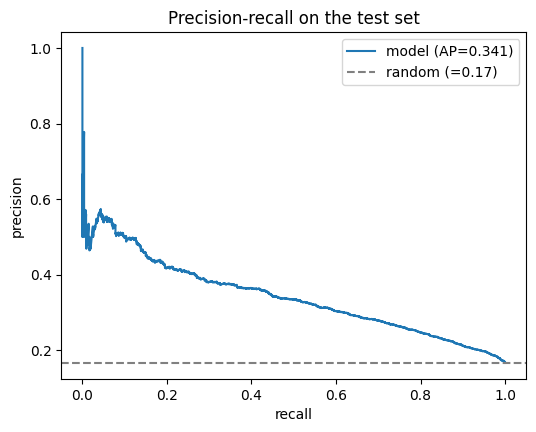

In [8]:
D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

## Task 5 - Does the hash dimension matter?

The heart of the assignment: sweep `D` and watch collisions trade off against memory.

In [9]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
    # TODO for each Dk:
    #   build train/test index matrices at dimension Dk
    Xtr = build_index_matrix(train_df,CAT_COLS,Dk)
    Xte = build_index_matrix(test_df,CAT_COLS,Dk)
    #   train logreg, predict on test
    w,b = train_logreg_sgd(Xtr,y_train,Dk, lr=0.1,epochs=3)
    #   record average_precision and log_loss
    p_te = predict_proba(Xte,w,b)

    ap = average_precision(y_test,p_te)
    ll = log_loss(y_test,p_te)

    ap_by_D.append(ap)
    ll_by_D.append(ll)
    #raise NotImplementedError

for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")

D=2^ 8  AP=0.263  logloss=0.4439
D=2^10  AP=0.299  logloss=0.4330
D=2^12  AP=0.323  logloss=0.4224
D=2^14  AP=0.337  logloss=0.4155
D=2^16  AP=0.340  logloss=0.4134
D=2^18  AP=0.341  logloss=0.4124


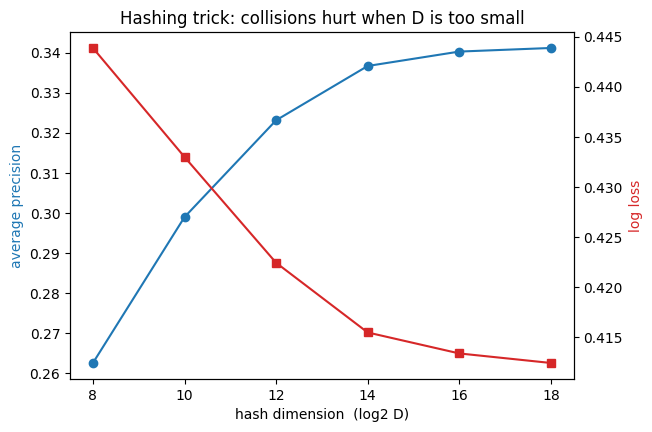

In [10]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

## Task 6 - Calibration

A good *ranking* is not enough for ad bidding; the predicted probabilities must mean what they say. Build a reliability curve.

In [11]:
def reliability_curve(y, p, n_bins=10):
    """Bin predictions into n_bins equal-width probability bins; return
    (mean_predicted, empirical_rate) per non-empty bin."""
    # TODO

    y = np.array(y)
    p = np.array(p)

    bins = np.linspace(0.0,1.0,n_bins+1)

    mean_pred = []
    emp_rate = []

    for i in range(n_bins):
        left,right = bins[i], bins[i+1]

        if i == n_bins - 1:
            mask = (p >= left) & (p <= right)
        else:
            mask = (p >= left) & (p < right)
        
        if np.sum(mask) == 0:
            continues

        mean_pred.append(np.mean(p[mask]))
        emp_rate.append(np.mean(y[mask]))

    return np.array(mean_pred), np.array(emp_rate)

    #raise NotImplementedError

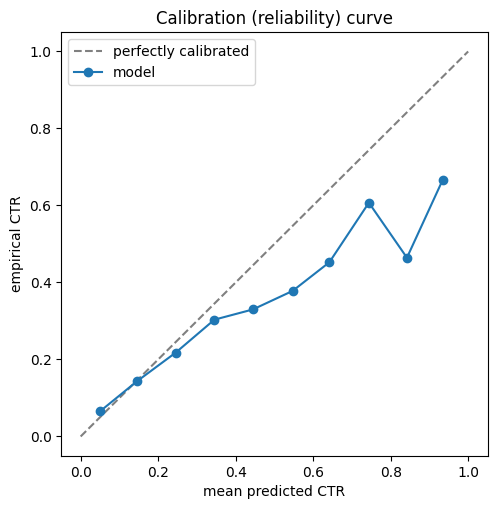

In [12]:
mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()

## Conceptual questions

1. The click rate is ~17%. What accuracy does the trivial "always predict
   no-click" model get, and why is accuracy the wrong headline metric here?
   Why are log-loss, average precision, and the PR curve more informative?
2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do
   you gain (memory, handling unseen values at test time) and what do you lose
   (collisions)? From your D sweep, where does shrinking D start to hurt, and why?
3. Restate the gradient you derived and explain why a hashed example updates only
   a handful of weights. Why does that make this model scale to billions of
   features?
4. Read your calibration curve. Are the predicted probabilities calibrated? Why
   does ad ranking/bidding (which multiplies predicted CTR by a bid) *need*
   calibrated probabilities, not just a good ranking?
5. Name one way to handle the class imbalance (class weights, threshold tuning,
   negative downsampling, ...). How would it move the PR curve and the calibration?


1. A model that predicts "no-click" would have an accuracy roughly of:

Accuracy = number of no-clicks/total examples = 83%

Although 83% sounds well, the model never identifies actual clicks since the dataset is imbalanced making auccracy misleading which therefore metrics reflect how useful the model is for finding clicks rather than predicting the class.

2. What is gained is lower memory usages due to no storing the dictionary of every possible feature value, scales to very large dataset, and can handle unseen values. What it losses is hashing collisions since there different features can map the same index and causing noise due to collusion from unrelated features that share the same weight. From sweep, different values of D performance remained stable when D was large enough but began to decline once D became to small. As D shrinks, collusion became more frequent causing the model difficulty to learn the spearation effects from different features causing metrics such as log-loss and average precision to get worst. 

3. Logisitc Regression:

p = sigma(z) = 1/(1+e^(-z)) ==> z = w^(t)x

Gradient of the log-loss with respect to each weight:

∂L/∂wj = (p-y)xj

wj <- wj - n(p-y)xj

p = predicted probability , y = true label , xj = feature j, n = learning rate

Since each example contains only a smaller number of the active hashed feature, most entries of x are zero. Only the nonzero features contribute to the gradient.

Each training example updates only a handful of weights instead of all D weights. Sparsing update makes the algorithm computationally effecient and allows to scale extremly large features even from the billions of possible features. 

4. The cuvre falls below the diagonal at higher probabilites, indicating the model is overestimating the likelyhood of clicks. A model that ranks correctly but produces innacurate probabilities may over or under value ads. Poor calibration leads to ineffcient spending and lower revenue. Stating, bidding systems require probabilites that accurately reflect true click rates and not just ordering of ads. 

5. A way to handle imbalances is to class the weights which causes the PR curve shift upward in regions of higher recall, which can decrease precision because more false positives may occur. Causing the predicted probabilites to become less calibrated since the training objective no longer reflects the true class distrubution. s



## What to submit

- This notebook with every `# TODO` completed and run top to bottom (the synthetic
  generator makes it fully reproducible; swap in the real Avazu frame if you want).
- The gradient derivation, the PR curve, the D-sweep figure, and the calibration curve.
- Written answers to the five conceptual questions.

**Grading (100 pts):** hashing trick (15), gradient derivation (15), SGD logreg
(20), imbalance-aware metrics + PR curve (20), hash-dimension sweep (15),
calibration + answers (15).
